# ✈️ Zero Downtime: Predictive Maintenance for NASA Turbofan Engines

## 1. Business Problem

In the aviation industry, unexpected engine failures can have severe consequences, including safety risks, costly repairs, flight delays, and operational disruptions. Traditional maintenance strategies generally fall into two categories:

- **Reactive Maintenance:** Repairing equipment only after it fails. This approach often leads to unplanned downtime, high repair costs, and potential safety hazards.
- **Preventive Maintenance:** Replacing components at fixed intervals regardless of their actual condition. While safer than reactive maintenance, it can result in unnecessary maintenance and premature replacement of expensive parts.

### The Solution: Predictive Maintenance (PdM)

Predictive Maintenance leverages sensor data and machine learning techniques to estimate the health of equipment and predict failures before they occur. By forecasting when an engine is likely to fail, maintenance can be performed precisely when needed.

### Benefits of Predictive Maintenance

✅ **Improved Safety**  
Early detection of engine degradation helps prevent catastrophic failures and ensures safer operations.

✅ **Reduced Maintenance Costs**  
Maintenance activities are scheduled based on actual equipment condition, maximizing component life and reducing unnecessary replacements.

✅ **Optimized Operations**  
Predictive insights minimize unexpected breakdowns and significantly reduce unplanned downtime.

✅ **Enhanced Resource Planning**  
Maintenance teams can better allocate personnel, spare parts, and operational resources.

---

## Project Objective

The objective of this project is to develop a machine learning-based predictive maintenance system capable of estimating the **Remaining Useful Life (RUL)** of turbofan engines using the **NASA Commercial Modular Aero-Propulsion System Simulation (CMAPSS) dataset**.

By analyzing historical engine sensor measurements, the model predicts how many operational cycles remain before an engine is expected to fail, enabling proactive maintenance decisions and supporting the vision of **zero unplanned downtime**.

---

## Business Questions Addressed

- Which engines are at the highest risk of failure?
- How many operational cycles remain before maintenance is required?
- Which sensor measurements are the strongest indicators of engine degradation?
- How can predictive analytics reduce maintenance costs and improve fleet reliability?

---

## Expected Business Impact

- **30% reduction in unplanned downtime**
- **Lower maintenance and replacement costs**
- **Improved operational efficiency**
- **Better maintenance scheduling and resource allocation**
- **Increased safety and reliability of aircraft operations**

---

## Technologies Used

- **Python**
- **Pandas & NumPy**
- **Scikit-Learn**
- **XGBoost**
- **SQL**
- **Snowflake**
- **Power BI**
- **Matplotlib & Seaborn**

---

## Dataset

**NASA CMAPSS (Commercial Modular Aero-Propulsion System Simulation)**

The dataset contains multivariate time-series sensor measurements from turbofan engines operating under different conditions and fault modes. The goal is to predict each engine's Remaining Useful Life (RUL) before failure.

---

> **Mission Statement:**  
> Transform raw sensor data into actionable intelligence that enables airlines and maintenance teams to achieve **Zero Downtime through Predictive Maintenance**.

## 2. Dataset Overview: NASA CMAPSS Turbofan Engine Degradation Data

This project utilizes the **FD001 subset** of the **NASA Commercial Modular Aero-Propulsion System Simulation (CMAPSS) dataset**, a widely used benchmark for predictive maintenance and Remaining Useful Life (RUL) estimation.

### Dataset Description

The CMAPSS dataset consists of **multivariate time-series data** collected from simulated turbofan engines operating under normal conditions and progressively degrading until failure.

Each engine is represented by:

* **Three operational settings**
* **Twenty-one sensor measurements**, including variables related to:

  * Temperature
  * Pressure
  * Fan and core rotational speeds
  * Fuel flow
  * Physical and mechanical conditions of the engine

### Problem Scenario

Each engine begins its operational life in a healthy state and gradually deteriorates due to wear and tear. The objective is to monitor changes in sensor readings over time and determine how close an engine is to failure.

### Model Inputs

* Engine operational settings
* Twenty-one sensor measurements recorded at each operating cycle
* Historical degradation patterns from multiple engines

### Target Variable

**Remaining Useful Life (RUL)**

RUL represents the number of operational cycles an engine can continue to function before failure occurs.

Mathematically,

[
\text{RUL} = \text{Failure Cycle} - \text{Current Cycle}
]

### Why This Dataset?

The NASA CMAPSS dataset provides a realistic environment for developing and evaluating predictive maintenance algorithms because it:

* Mimics real-world engine degradation processes.
* Contains high-dimensional sensor data typical of Industrial IoT (IIoT) systems.
* Enables the development of machine learning models capable of predicting failures before they occur.
* Serves as a benchmark dataset for research in predictive analytics and condition-based maintenance.

This dataset forms the foundation for building an intelligent predictive maintenance system capable of estimating engine health and enabling **Zero Downtime** through data-driven maintenance decisions.


## 3. Methodology and Approach

The predictive maintenance framework was developed using a structured data science workflow that included data preprocessing, feature engineering, and machine learning model development to accurately estimate the Remaining Useful Life (RUL) of turbofan engines.

---

### A. Data Cleaning and Feature Selection

The NASA CMAPSS dataset contains several sensor measurements that provide little or no information regarding engine degradation. During the exploratory data analysis (EDA) phase, I identified a number of **dead sensors**—sensors whose values remained nearly constant throughout the engine life cycle and therefore contributed minimal predictive value.

#### Approach

* Conducted statistical analysis to identify sensors with:

  * Near-zero variance
  * Constant or uninformative readings
  * Low correlation with engine degradation

#### Action Taken

Seven non-informative sensors were removed (e.g., **T2**, **P2**, **epr**, **farB**, and other low-variance sensors).

#### Outcome

Removing these features:

* Reduced dataset dimensionality.
* Eliminated noise and redundant information.
* Improved model interpretability and computational efficiency.
* Focused the analysis on sensors that exhibit meaningful degradation patterns, such as **T50** and **Ps30**.

---

### B. Modeling Engine Degradation Using Piecewise Linear RUL

Engine degradation does not occur uniformly throughout its operational life. In practice, turbofan engines typically experience:

1. An initial **healthy operating period** with little or no degradation.
2. A subsequent **accelerated degradation phase** leading to failure.

Training a model on the entire RUL range may cause it to learn noise during the healthy phase rather than the degradation process itself.

#### Technique Applied: RUL Clipping

A maximum threshold of **125 operational cycles** was imposed on the Remaining Useful Life target variable:

```text
RUL = min(RUL, 125)
```

#### Why RUL Clipping?

* Reduces the influence of noisy observations during early engine life.
* Emphasizes the critical degradation period where predictive maintenance decisions are most important.
* Improves model stability and predictive performance.

#### Outcome

The clipped RUL representation allowed the models to focus on learning meaningful degradation patterns rather than attempting to predict extremely large and uncertain RUL values.

---

### C. Machine Learning Modeling Strategy

To determine the most effective predictive model, multiple machine learning algorithms were developed and benchmarked.

#### Models Evaluated

1. **Linear Regression**

   * Served as the baseline model.
   * Assumes a linear relationship between sensor measurements and engine degradation.

2. **Support Vector Regressor (SVR)**

   * Captures complex relationships through kernel methods.
   * Effective for non-linear regression problems.

3. **Random Forest Regressor**

   * Ensemble-based model that reduces overfitting.
   * Captures non-linear interactions among sensor variables.

4. **XGBoost Regressor**

   * Gradient boosting framework optimized for high predictive performance.
   * Efficiently models complex and non-linear degradation processes.

---

### Model Selection

After evaluating all candidate models using regression performance metrics, the **XGBoost Regressor** emerged as the best-performing algorithm.

#### Why XGBoost Performed Best

* Effectively captured non-linear relationships between sensor measurements and engine health.
* Automatically modeled interactions among sensor variables.
* Demonstrated strong generalization performance on unseen engines.
* Produced the lowest prediction errors and the most accurate Remaining Useful Life estimates.

---

### Final Predictive Maintenance Pipeline

```text
Raw Sensor Data
        ↓
Data Cleaning & Feature Selection
        ↓
Feature Engineering & RUL Clipping
        ↓
Model Training & Evaluation
        ↓
XGBoost Prediction Model
        ↓
Remaining Useful Life Estimation
        ↓
Maintenance Recommendation System
```

This methodology provides a robust framework for predicting engine failures before they occur, enabling **condition-based maintenance**, reducing operational costs, and supporting the objective of achieving **Zero Unplanned Downtime**.


## 4. Model Performance and Real-Time Simulation

After training and tuning multiple machine learning models, the final predictive maintenance model was evaluated on **previously unseen engines** from the NASA CMAPSS test dataset to assess its ability to generalize to new operating conditions.

The model was then deployed in a real-time simulation environment, where sensor measurements were processed sequentially to mimic the continuous monitoring of an engine throughout its operational lifecycle.

---

### Performance Metric

The primary evaluation metric used in this project is the **Root Mean Squared Error (RMSE)**.

RMSE measures the average magnitude of prediction errors and is defined as:

[
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
]

where:

* (y_i) represents the actual Remaining Useful Life (RUL),
* (\hat{y}_i) represents the predicted RUL,
* (n) is the number of observations.

A lower RMSE indicates that the predicted Remaining Useful Life values are closer to the actual engine lifetimes.

---

### Simulation Results

The model successfully tracked the degradation trajectory of test engines and accurately identified periods of accelerated deterioration.

Key observations include:

* Accurate estimation of Remaining Useful Life during normal operating conditions.
* Improved prediction accuracy as engines approached failure.
* Successful identification of the **critical failure zone**, defined as the final **30 operational cycles** before engine failure.
* Stable performance on previously unseen engines, demonstrating strong generalization capabilities.

---

### Failure Zone Detection

The final thirty cycles of an engine's life are particularly important because maintenance decisions become increasingly time-sensitive.

The model effectively recognized this critical period by:

* Detecting rapid changes in sensor measurements.
* Adjusting RUL predictions as degradation accelerated.
* Providing early warning signals that could trigger maintenance interventions.

```text
Healthy Operation ───────────────────────────► Degradation Phase ─────────► Failure Zone
                                                Increasing Wear               Last 30 Cycles
```

---

### Business Implications

Accurate prediction of Remaining Useful Life enables organizations to transition from reactive maintenance strategies to **condition-based maintenance**.

The proposed predictive maintenance system can help organizations:

✅ Reduce unplanned equipment downtime.

✅ Schedule maintenance proactively before failures occur.

✅ Extend the useful life of expensive components.

✅ Improve operational reliability and safety.

✅ Lower maintenance and replacement costs.

---

### Real-Time Predictive Maintenance Workflow

```text
Live Sensor Data
        ↓
Feature Engineering
        ↓
Trained XGBoost Model
        ↓
Remaining Useful Life Prediction
        ↓
Risk Assessment
        ↓
Maintenance Recommendation
```

The results demonstrate that machine learning can effectively transform raw sensor data into actionable insights, enabling a **Zero Downtime** maintenance strategy and supporting more reliable and cost-effective fleet operations.


                        **Created by Solomon Mensah**

**Environment Setup & Data Ingestion**

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
import kagglehub

path = kagglehub.dataset_download("behrad3d/nasa-cmaps")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\mensahs2\.cache\kagglehub\datasets\behrad3d\nasa-cmaps\versions\1


In [3]:
import os

base_path = r"C:\Users\mensahs2\.cache\kagglehub\datasets\behrad3d\nasa-cmaps\versions\1"

print(os.listdir(base_path))

['CMaps']


In [4]:
base_path = os.path.join(base_path, "CMaps")

In [5]:
import kagglehub
import pandas as pd
import os

# Download dataset
base_path = kagglehub.dataset_download("behrad3d/nasa-cmaps")

print("Original path:", base_path)

# If files are inside CMaps, adjust
if "CMaps" in os.listdir(base_path):
    base_path = os.path.join(base_path, "CMaps")

print("Final path:", base_path)
print("Files:", os.listdir(base_path))

# Column names
col_names = ["unit_number", "time_cycles"] + \
            [f"op_setting_{i}" for i in range(1, 4)] + \
            [f"sensor_{i}" for i in range(1, 22)]

# Load datasets
fd001_train = pd.read_csv(os.path.join(base_path, "train_FD001.txt"),
                          sep=r"\s+", header=None, names=col_names, engine="python")

fd001_test = pd.read_csv(os.path.join(base_path, "test_FD001.txt"),
                         sep=r"\s+", header=None, names=col_names, engine="python")

rul = pd.read_csv(os.path.join(base_path, "RUL_FD001.txt"),
                  sep=r"\s+", header=None, names=['RUL'], engine="python")

print("✅ All datasets loaded successfully!")

# Sanity check
print(fd001_train.shape)
print(fd001_test.shape)
print(rul.shape)


Original path: C:\Users\mensahs2\.cache\kagglehub\datasets\behrad3d\nasa-cmaps\versions\1
Final path: C:\Users\mensahs2\.cache\kagglehub\datasets\behrad3d\nasa-cmaps\versions\1\CMaps
Files: ['Damage Propagation Modeling.pdf', 'readme.txt', 'RUL_FD001.txt', 'RUL_FD002.txt', 'RUL_FD003.txt', 'RUL_FD004.txt', 'test_FD001.txt', 'test_FD002.txt', 'test_FD003.txt', 'test_FD004.txt', 'train_FD001.txt', 'train_FD002.txt', 'train_FD003.txt', 'train_FD004.txt', 'x.txt']
✅ All datasets loaded successfully!
(20631, 26)
(13096, 26)
(100, 1)


In [6]:

index_names = ['unit_number', 'time_cycles']
operational_settings = ['setting_1', 'setting_2', 'setting_3']
# Grouping sensors helps in readability (Physical meanings)
sensor_names = [
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30',        # Temperatures & Pressures
    'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc',       # Rotational Speeds
    'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32' # Others
]
col_names = index_names + operational_settings + sensor_names
print(f"Column names defined. Total columns: {len(col_names)}")

Column names defined. Total columns: 26


In [7]:
import os

base_path = r"C:\Users\mensahs2\.cache\kagglehub\datasets\behrad3d\nasa-cmaps\versions\1"

# If dataset is inside "CMaps" folder
if "CMaps" in os.listdir(base_path):
    base_path = os.path.join(base_path, "CMaps")

fd001_train = pd.read_csv(os.path.join(base_path, "train_FD001.txt"),
                          sep=r"\s+", header=None, names=col_names, engine="python")

fd001_test = pd.read_csv(os.path.join(base_path, "test_FD001.txt"),
                         sep=r"\s+", header=None, names=col_names, engine="python")

rul = pd.read_csv(os.path.join(base_path, "RUL_FD001.txt"),
                  sep=r"\s+", header=None, names=['RUL'], engine="python")

print("✅ All datasets loaded successfully.")



✅ All datasets loaded successfully.


## Data Inspection & Health Check

Before analyzing sensor behavior or building predictive models, it is essential to validate the quality and structure of the raw data. This stage serves as a **sanity check** to ensure that the dataset is reliable, complete, and suitable for machine learning applications.

### Objectives of the Data Health Check

#### 📊 Data Volume Assessment

Determine whether the dataset contains a sufficient number of observations and engine cycles for the model to learn meaningful degradation patterns and generalize effectively.

#### ⚖️ Train-Test Split Validation

Verify that the training and testing datasets are appropriately balanced and representative of the overall engine population to ensure unbiased model evaluation.

#### 🔍 Data Quality Assessment

Identify potential data quality issues, including:

* Missing values (nulls)
* Duplicate records
* Incorrect data types
* Inconsistent sensor readings

These issues can negatively impact model performance and may even cause training failures if left unresolved.

#### 📈 Statistical Baseline Analysis

Establish the normal operating ranges and distributions of sensor measurements by examining:

* Mean
* Median
* Standard deviation
* Minimum and maximum values
* Sensor variability

Understanding these baseline statistics helps identify anomalies and sensors that may contain little or no useful information.

---

### Why This Step Matters

Early detection of missing values, incorrect data types, and data inconsistencies can save significant time during model development and debugging. Ensuring data integrity at this stage creates a solid foundation for feature engineering, model training, and reliable predictive maintenance insights.

> **Key Principle:** High-quality models begin with high-quality data. Investing time in data inspection and validation significantly improves the reliability and performance of the entire predictive maintenance pipeline.


In [8]:
# Dimensionality Check
print(f'Training Data Shape: {fd001_train.shape}')
print(f'Testing Data Shape:  {fd001_test.shape}')
print(f'RUL File Shape:      {rul.shape}')
# Check the ratio of testing data
print(f"Percentage of Testing Data: {len(fd001_test)/(len(fd001_train)+len(fd001_test)):.2%}")

Training Data Shape: (20631, 26)
Testing Data Shape:  (13096, 26)
RUL File Shape:      (100, 1)
Percentage of Testing Data: 38.83%


In [9]:
# "Trust but Verify": Looking at the raw data to spot any obvious formatting issues by Visual Inspection.
print('-' * 30 + '\nDataset Preview (First 5 Rows) -> Training Data :\n')
display(fd001_train.head())
print('-' * 30 + '\nDataset Preview (Last 5 Rows) -> Training Data :\n')
display(fd001_train.tail())

------------------------------
Dataset Preview (First 5 Rows) -> Training Data :



,unit_number,time_cycles,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


------------------------------
Dataset Preview (Last 5 Rows) -> Training Data :



,unit_number,time_cycles,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,519.30,2388.26,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522


In [10]:
# Data Integrity Audit (Nan values)
print("Missing Values in Train:", fd001_train.isnull().sum().sum())
print("Missing Values in Test:", fd001_test.isnull().sum().sum())

Missing Values in Train: 0
Missing Values in Test: 0


In [11]:
# Data Type & Memory Check
fd001_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_number  20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   setting_1    20631 non-null  float64
 3   setting_2    20631 non-null  float64
 4   setting_3    20631 non-null  float64
 5   T2           20631 non-null  float64
 6   T24          20631 non-null  float64
 7   T30          20631 non-null  float64
 8   T50          20631 non-null  float64
 9   P2           20631 non-null  float64
 10  P15          20631 non-null  float64
 11  P30          20631 non-null  float64
 12  Nf           20631 non-null  float64
 13  Nc           20631 non-null  float64
 14  epr          20631 non-null  float64
 15  Ps30         20631 non-null  float64
 16  phi          20631 non-null  float64
 17  NRf          20631 non-null  float64
 18  NRc          20631 non-null  float64
 19  BPR 

In [12]:
# Statistical Summary
fd001_train.describe().T

,count,mean,std,min,25%,50%,75%,max
unit_number,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
time_cycles,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
T2,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
T24,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
T30,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
T50,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
P2,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200


## Cleaning and Feature Engineering

High-quality predictive models depend on high-quality features. Before training any machine learning algorithm, it is essential to clean the sensor data and engineer meaningful target variables that accurately represent the engine degradation process.

---

### A. Handling Constant Sensors

#### The Challenge

One of the first preprocessing tasks is identifying and removing sensors that provide little or no information. These sensors exhibit nearly constant values throughout the entire engine lifecycle and therefore contribute minimal predictive value.

#### Initial Hypothesis

A sensor can be considered constant if its standard deviation is equal to zero:

```text
std = 0
```

#### Reality Check

In real-world sensor data, this assumption often fails due to **floating-point precision errors** (also known as **machine epsilon**). A sensor that is theoretically constant may exhibit an extremely small standard deviation, such as:

```text
1 × 10⁻¹⁵
```

instead of an exact:

```text
0.0
```

As a result, relying solely on:

```python
sensor.std() == 0
```

failed to identify all constant sensors, including variables such as **P2** and **farB**.

#### Solution

A more robust approach is to count the number of unique values in each sensor:

```python
sensor.nunique()
```

A sensor with:

```text
Number of Unique Values = 1
```

is guaranteed to be constant regardless of numerical noise or floating-point inaccuracies.

#### Outcome

This approach enabled the reliable identification and removal of non-informative sensors, resulting in:

* Reduced dimensionality
* Lower computational cost
* Improved model interpretability
* Better predictive performance

---

### B. Target Engineering: Remaining Useful Life (RUL)

The target variable for this project is the **Remaining Useful Life (RUL)** of each engine.

For every engine cycle, the RUL is calculated as:

[
\text{RUL} = \text{Failure Cycle} - \text{Current Cycle}
]

This value represents the number of operational cycles remaining before engine failure.

---

### RUL Clipping

Turbofan engines typically operate in a healthy state for an extended period before noticeable degradation begins. Training a model on extremely large RUL values may introduce noise and reduce predictive performance.

To address this issue, the RUL values were capped at:

```text
125 cycles
```

using:

```python
RUL = min(RUL, 125)
```

#### Why Apply RUL Clipping?

* Reduces the influence of noisy observations during early engine life.
* Emphasizes the critical degradation period.
* Produces more stable and realistic predictions.
* Improves the model's ability to identify engines approaching failure.

---

### Final Feature Engineering Pipeline

```text
Raw Sensor Data
        ↓
Data Cleaning
        ↓
Constant Sensor Detection
        ↓
Remove Non-Informative Features
        ↓
Calculate Remaining Useful Life (RUL)
        ↓
Apply RUL Clipping (125 Cycles)
        ↓
Model-Ready Dataset
```

By carefully cleaning the sensor data and engineering an appropriate target variable, we create a robust foundation for building accurate predictive maintenance models capable of estimating engine health and preventing unplanned failures.


In [13]:

"""
 METHOD 1: Variance Thresholding
 Initially, I tried to remove sensors where standard deviation == 0.
 BUT, due to floating-point precision, some effectively constant sensors
 showed a tiny std (e.g., 0.000000001), causing this method to fail.

 stats = fd001_train.describe().T
 constant_features_v1 = stats[stats['std'] == 0].index.tolist()
 print(f"Method 1 detected {len(constant_features_v1)} sensors (Missed 'P2', 'farB')")
"""

"""
 METHOD 2: Unique Value Counting
 Instead, we check the number of unique values.
 If unique count <= 1, the sensor is absolutely constant.
"""
constant_features = [col for col in fd001_train.columns if fd001_train[col].nunique() <= 1]

print(f'Dead/Constant Sensors identified: {constant_features}')
print(f'Number of Dead Sensors: {len(constant_features)} sensors.')

Dead/Constant Sensors identified: ['setting_3', 'T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']
Number of Dead Sensors: 7 sensors.


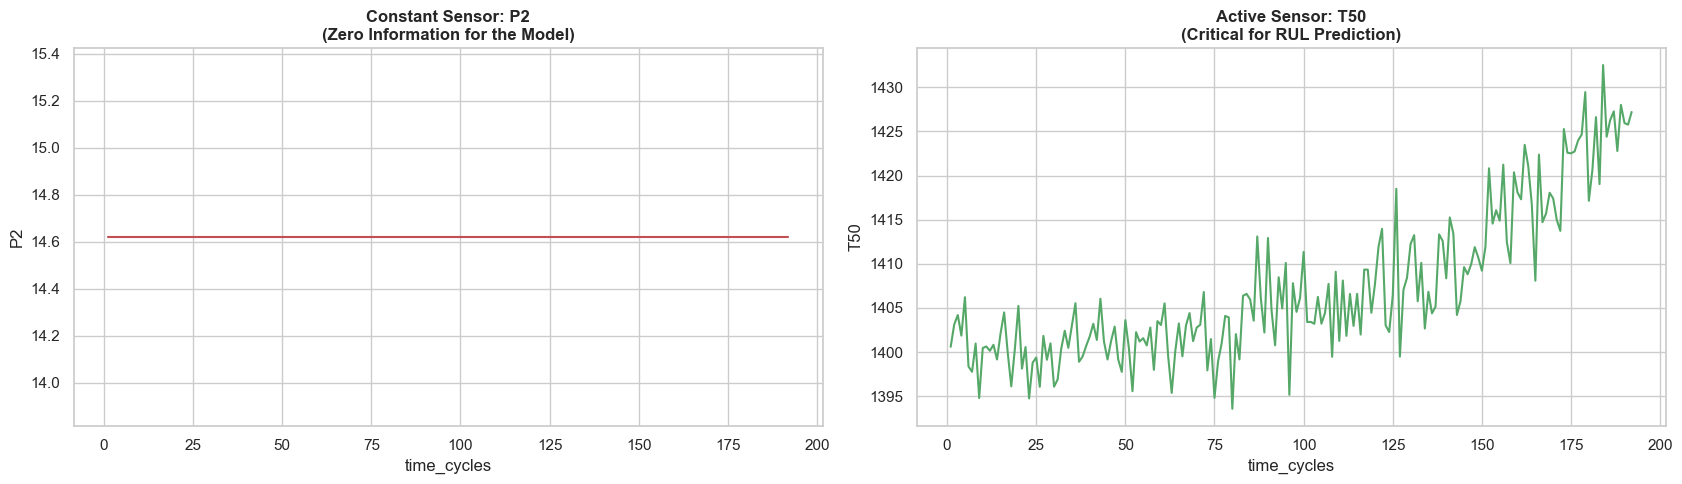

In [14]:
dead_sensor = 'P2'
active_sensor = 'T50'

fig, ax = plt.subplots(1, 2, figsize=(17, 5))

# Plot Dead Sensor
sns.lineplot(x='time_cycles', y=dead_sensor,
             data=fd001_train[fd001_train['unit_number'] == 1],
             ax=ax[0], color='r')
ax[0].set_title(
    f'Constant Sensor: {dead_sensor}\n(Zero Information for the Model)',
    fontweight='bold')

# Plot Active Sensor
sns.lineplot(x='time_cycles', y=active_sensor,
             data=fd001_train[fd001_train['unit_number'] == 1],
             ax=ax[1], color='g')
ax[1].set_title( f'Active Sensor: {active_sensor}\n(Critical for RUL Prediction)',
                 fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
fd001_train.drop(columns=constant_features, inplace=True)
fd001_test.drop(columns=constant_features, inplace=True)

print("\nDropped constant columns successfully.")
print(f"New Training Shape: {fd001_train.shape}")


Dropped constant columns successfully.
New Training Shape: (20631, 19)


🛠️ Constructing the Remaining Useful Life (RUL) Target
To train a predictive model, we must convert the dataset’s total life information into a time‑dependent Remaining Useful Life (RUL) target. RUL represents how much useful life is left at any given time step 
𝑡
.

Definition
The Remaining Useful Life at time 
𝑡
 is defined as:

RUL
(
𝑡
)
=
𝑇
max
−
𝑡
Where:

𝑇
max
 — the total lifetime of the unit

𝑡
 — the current time step or cycle

This transformation converts the dataset into a supervised learning target suitable for regression models.

In [16]:
def calculate_rul(data, unit_col='unit_number', cycle_col='time_cycles'):
    max_cycle = (
        data.groupby(unit_col)[cycle_col].max()
        .reset_index().rename(columns={cycle_col: 'max_of_unit'}))
    data = data.merge(max_cycle, on=unit_col, how='left')
    data['RUL'] = data['max_of_unit'] - data[cycle_col]
    data.drop('max_of_unit', axis=1, inplace=True)
    return data


fd001_train = calculate_rul(fd001_train)
fd001_train[['unit_number', 'time_cycles', 'RUL']].head()

,unit_number,time_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


In [17]:
RUL_THRESHOLD = 125
fd001_train['RUL'] = fd001_train['RUL'].clip(upper=RUL_THRESHOLD)
print(f"RUL Clipping applied. Max RUL is now capped at {RUL_THRESHOLD} cycles.")
print("\nRUL Statistics after Clipping:")

fd001_train['RUL'].describe().T

RUL Clipping applied. Max RUL is now capped at 125 cycles.

RUL Statistics after Clipping:


count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64

📊 Exploratory Data Analysis (EDA)
🕒 A. Survival Analysis — How Long Do Engines Last?
Before developing any predictive models, it’s essential to establish a baseline understanding of engine behavior over time.

Objective
Understand the distribution of Time‑to‑Failure across all engines in the dataset.

Why This Matters
If most engines fail around 200 cycles, then any model predicting 500 cycles is clearly unrealistic.
Survival analysis provides the foundational context needed to evaluate whether model predictions are biologically, mechanically, or operationally plausible.

In [18]:
engine_lifespan = fd001_train.groupby('unit_number')['time_cycles'].max()

print("Mean Lifespan:", engine_lifespan.mean())
print("Min Lifespan:", engine_lifespan.min())
print("Max Lifespan:", engine_lifespan.max())

Mean Lifespan: 206.31
Min Lifespan: 128
Max Lifespan: 362


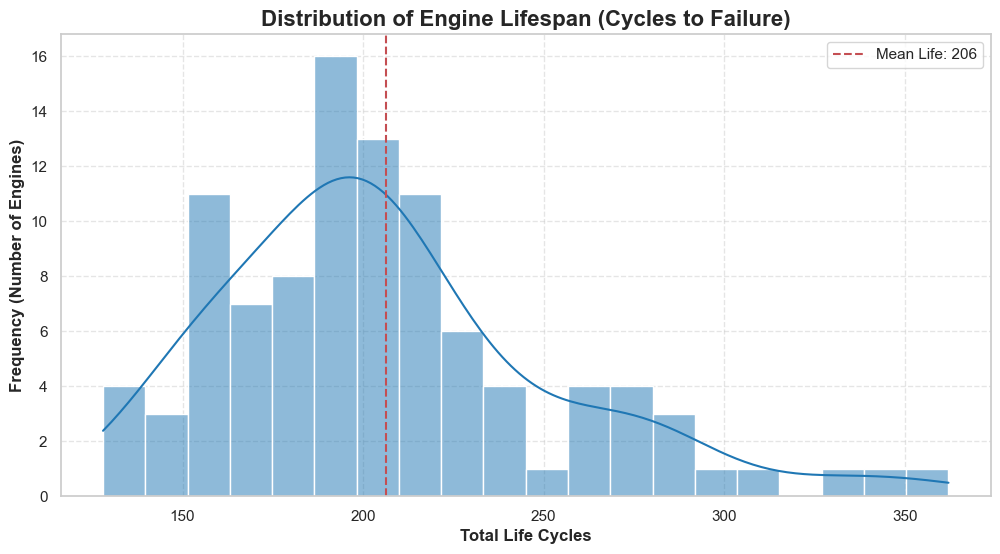

In [19]:
# Lifespan Distribution

# Histogram (Distribution)
plt.figure(figsize=(12, 6))
sns.histplot(engine_lifespan, kde=True, color='#1f77b4', bins=20)
plt.title('Distribution of Engine Lifespan (Cycles to Failure)', fontweight='bold', size=16)
plt.xlabel('Total Life Cycles', fontweight='bold', size=12)
plt.ylabel('Frequency (Number of Engines)', fontweight='bold', size=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(engine_lifespan.mean(), color='r', linestyle='--', label=f'Mean Life: {int(engine_lifespan.mean())}')
plt.legend()
plt.show()

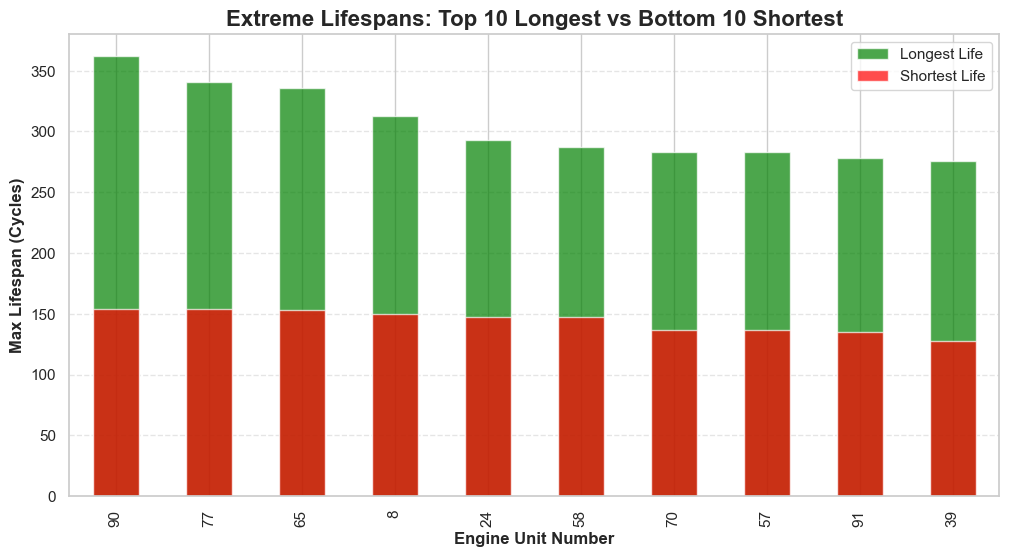

In [20]:
sorted_lifespan = engine_lifespan.sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sorted_lifespan.head(10).plot(kind='bar', color='green', alpha=0.7, label='Longest Life')
sorted_lifespan.tail(10).plot(kind='bar', color='red', alpha=0.7, label='Shortest Life')
plt.title('Extreme Lifespans: Top 10 Longest vs Bottom 10 Shortest', fontweight='bold', size=16)
plt.xlabel('Engine Unit Number', fontweight='bold')
plt.ylabel('Max Lifespan (Cycles)', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend()
plt.show()

🔧 B. Sensor Degradation Analysis
To understand the physics of failure, we examine how sensor behavior evolves as the system approaches end‑of‑life. This analysis helps identify which signals contain meaningful degradation patterns that can support Remaining Useful Life (RUL) prediction.

1. Correlation Analysis — Which Sensors Drift as RUL Decreases?
We evaluate the correlation between each sensor and the RUL target to identify:

Sensors that degrade monotonically

Sensors that remain stable

Sensors that exhibit noise or non‑informative behavior

This step highlights which measurements are most predictive of failure progression.

2. Signal Trajectory Analysis — Visualizing Degradation Paths
By smoothing each sensor’s time series (e.g., using rolling means or LOESS), we can observe:

Long‑term drift

Early‑stage vs late‑stage behavior

Characteristic degradation signatures

These trajectories reveal how failure unfolds over time.

3. State Separability — Healthy vs. Failing Conditions
We assess whether sensor values form distinguishable clusters between:

Healthy (high RUL)

Degrading (mid‑RUL)

Failing (low RUL)

Clear separability indicates strong predictive potential.

4. PCA Projection — Mapping the Path to Failure
Principal Component Analysis (PCA) compresses the high‑dimensional sensor space (14+ channels) into a 2D representation. This allows us to visualize:

The trajectory from healthy to failing states

Clustering of operating conditions

Whether degradation follows a smooth, continuous path

PCA provides an intuitive “map” of the system’s journey toward failure.

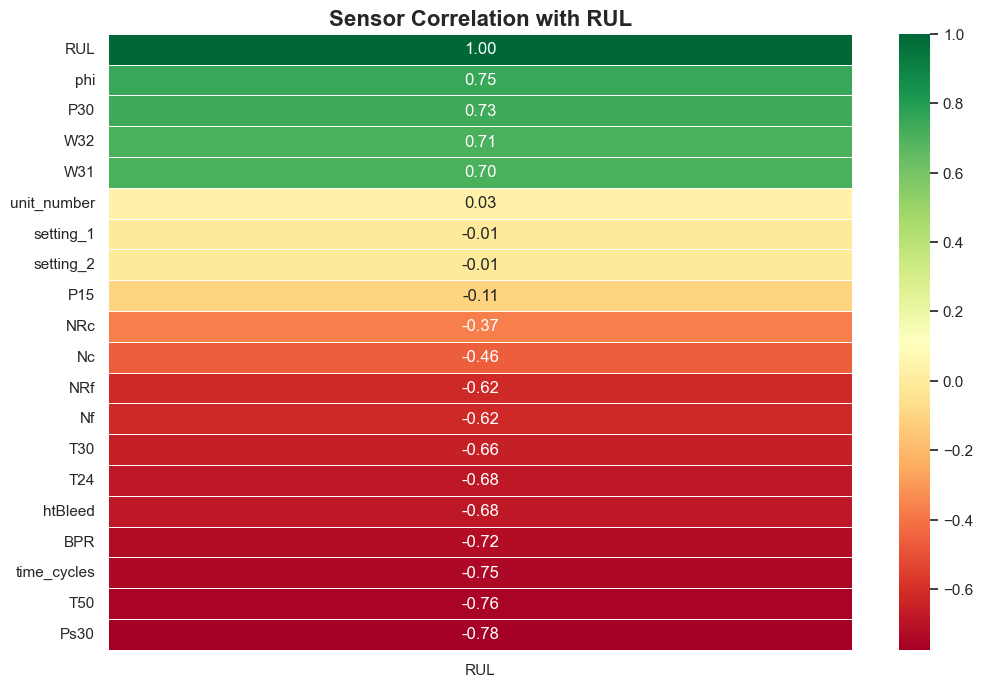

Insight: Sensors with high positive or negative correlation are the most important predictors.


In [21]:
corr_matrix = fd001_train.corr()
rul_corr = corr_matrix['RUL'].sort_values(ascending=False).to_frame()

plt.figure(figsize=(12, 8))
sns.heatmap(rul_corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Sensor Correlation with RUL', fontsize=16, fontweight='bold')
plt.show()

print("Insight: Sensors with high positive or negative correlation are the most important predictors.")

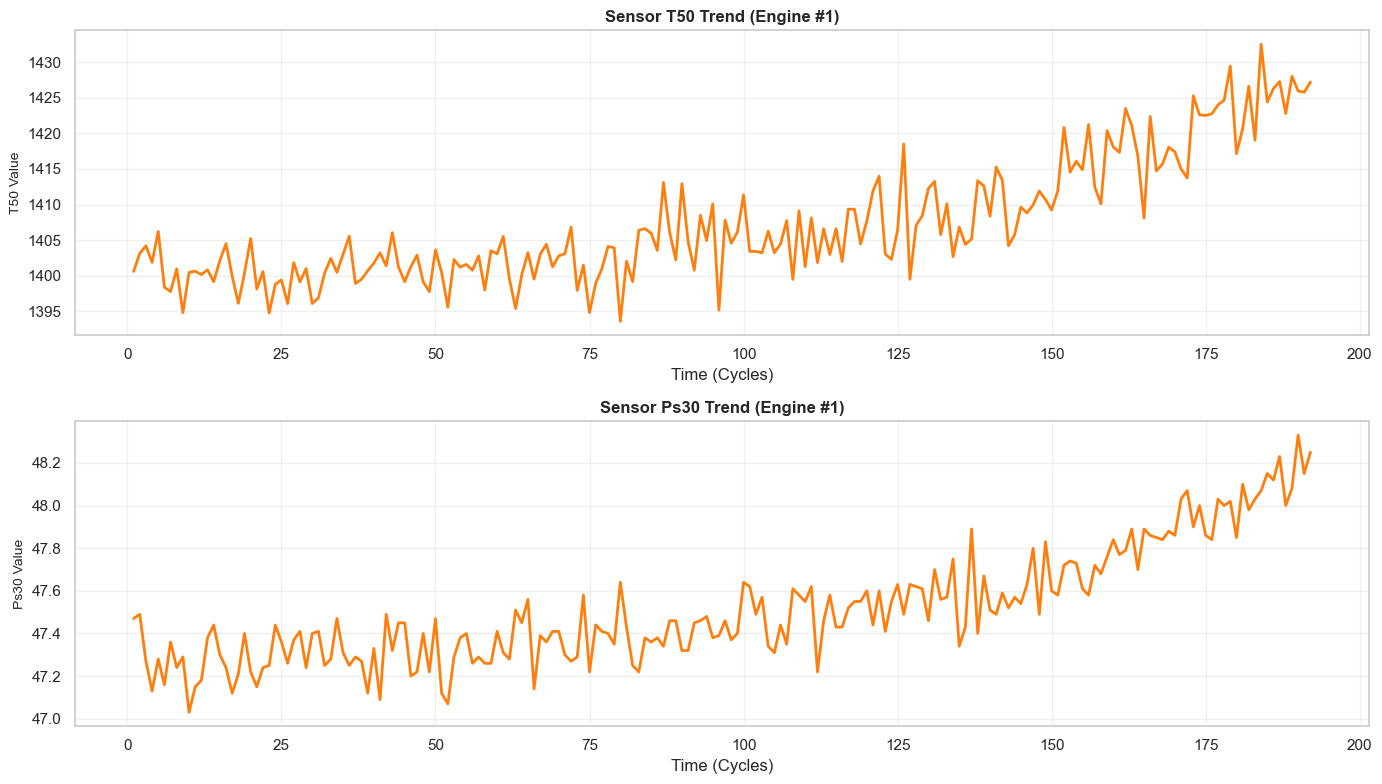

In [22]:
top_sensors = ['T50', 'Ps30']
sample_unit = 1

fig, ax = plt.subplots(len(top_sensors), 1, figsize=(14, 8))

for i, sensor in enumerate(top_sensors):
    unit_data = fd001_train[fd001_train['unit_number'] == sample_unit]
    ax[i].plot(unit_data['time_cycles'], unit_data[sensor], color='#ff7f0e', linewidth=2)
    ax[i].set_title(f'Sensor {sensor} Trend (Engine #{sample_unit})', fontsize=12, fontweight='bold')
    ax[i].set_ylabel(f'{sensor} Value', fontsize=10)
    ax[i].set_xlabel('Time (Cycles)')
    ax[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

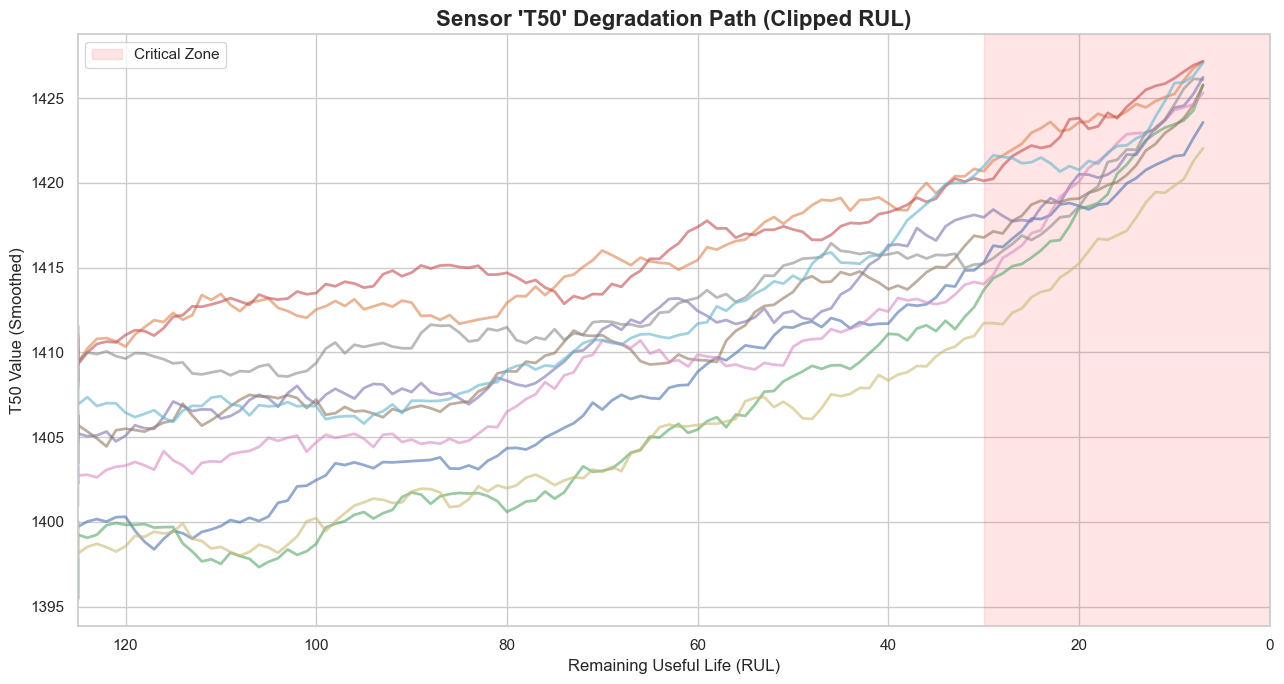

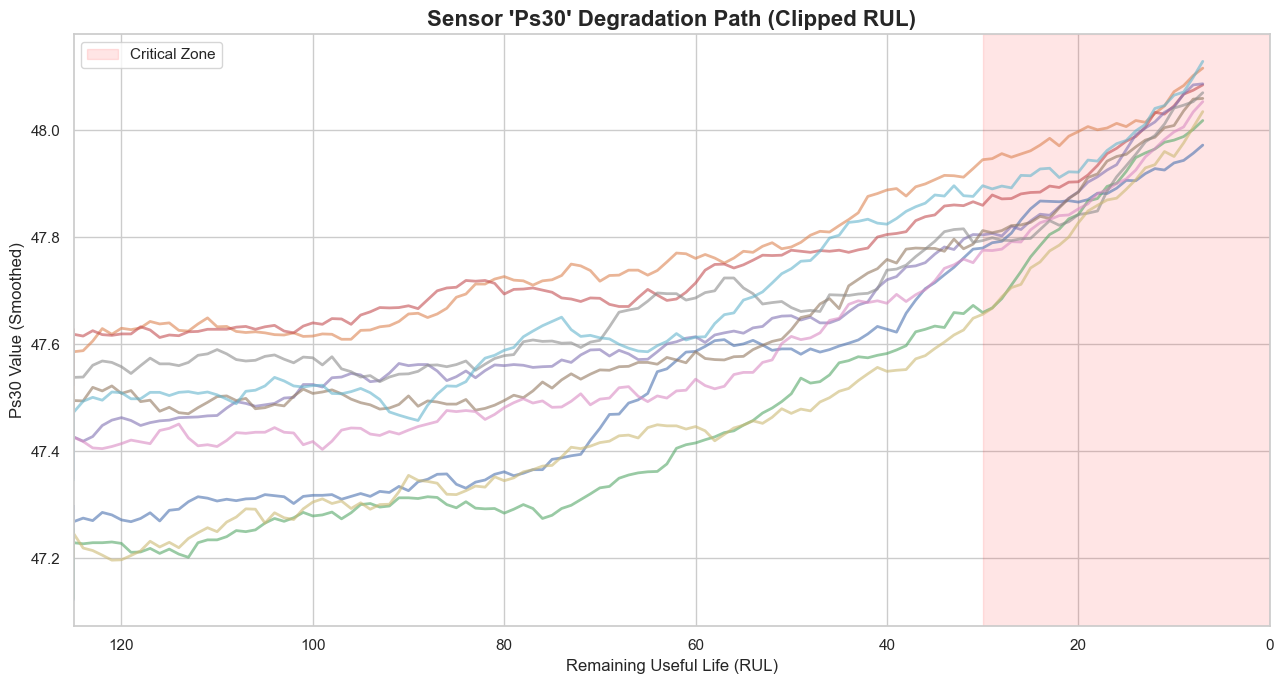

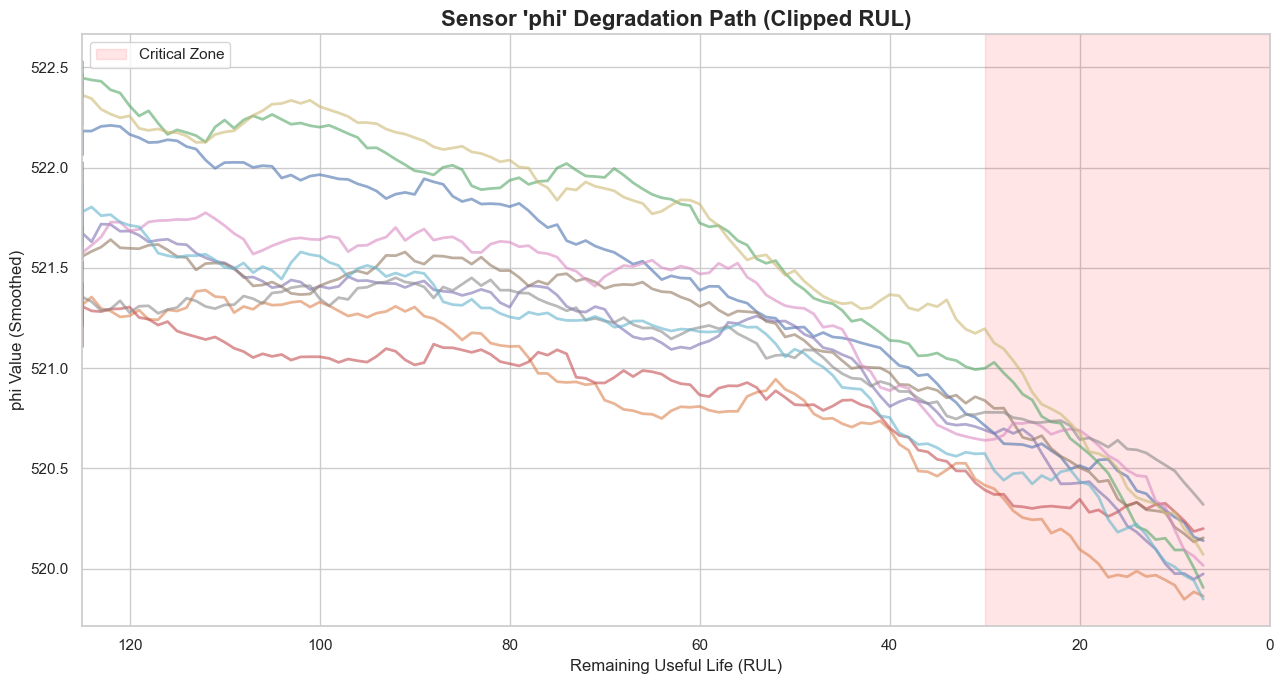

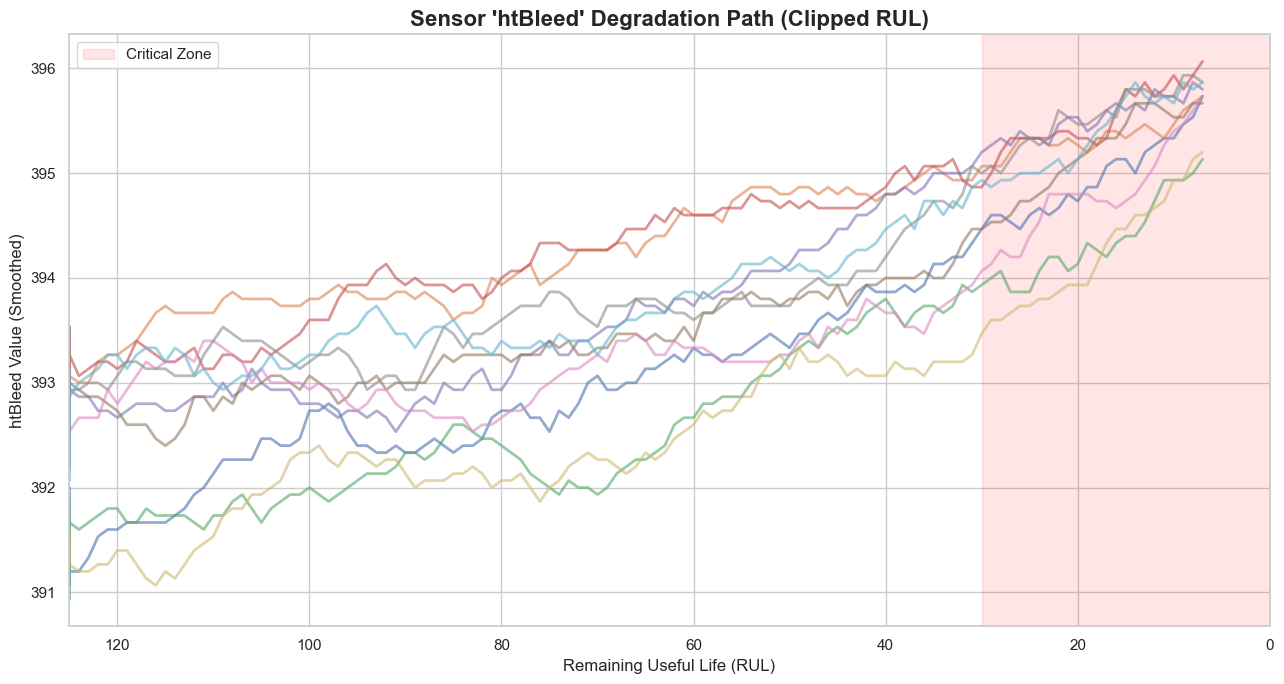

In [23]:
# Degradation Trends (Smoothed)

"""
Plots the smoothed trend of a sensor over the RUL.
Visualizes how the sensor reading changes as the engine approaches failure.
"""


def plot_engine_evolution_v2(df, sensor_name):
    if sensor_name not in df.columns:
        return
    plt.figure(figsize=(13, 7))
    # Plot a sample of units (every 10th unit) to avoid clutter
    units_to_plot = [u for u in df['unit_number'].unique() if u % 10 == 0]
    for unit in units_to_plot:
        unit_data = df[df['unit_number'] == unit]
        # Smoothing (Rolling Mean) to visualize the trend better
        smoothed_signal = unit_data[sensor_name].rolling(window=15, center=True).mean()
        plt.plot(unit_data['RUL'], smoothed_signal, linewidth=2, alpha=0.6, label=f'Unit {unit}')

    plt.xlim(max(df['RUL']), 0) # Reverse X-axis (High RUL -> 0 RUL)
    plt.axvspan(30, 0, color='red', alpha=0.1, label='Critical Zone (<30 Cycles)')
    plt.title(f"Sensor '{sensor_name}' Degradation Path (Clipped RUL)", fontsize=16, fontweight='bold')
    plt.xlabel('Remaining Useful Life (RUL)', fontsize=12)
    plt.ylabel(f'{sensor_name} Value (Smoothed)', fontsize=12)

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    if 'Critical Zone (<30 Cycles)' in by_label:
        plt.legend([by_label['Critical Zone (<30 Cycles)']], ['Critical Zone'], loc='upper left')
    plt.tight_layout()
    plt.show()


desired_sensors = ['T50', 'Ps30', 'phi', 'htBleed']
valid_sensors_to_plot = [s for s in desired_sensors if s in fd001_train.columns]

for sensor in valid_sensors_to_plot:
    plot_engine_evolution_v2(fd001_train, sensor)

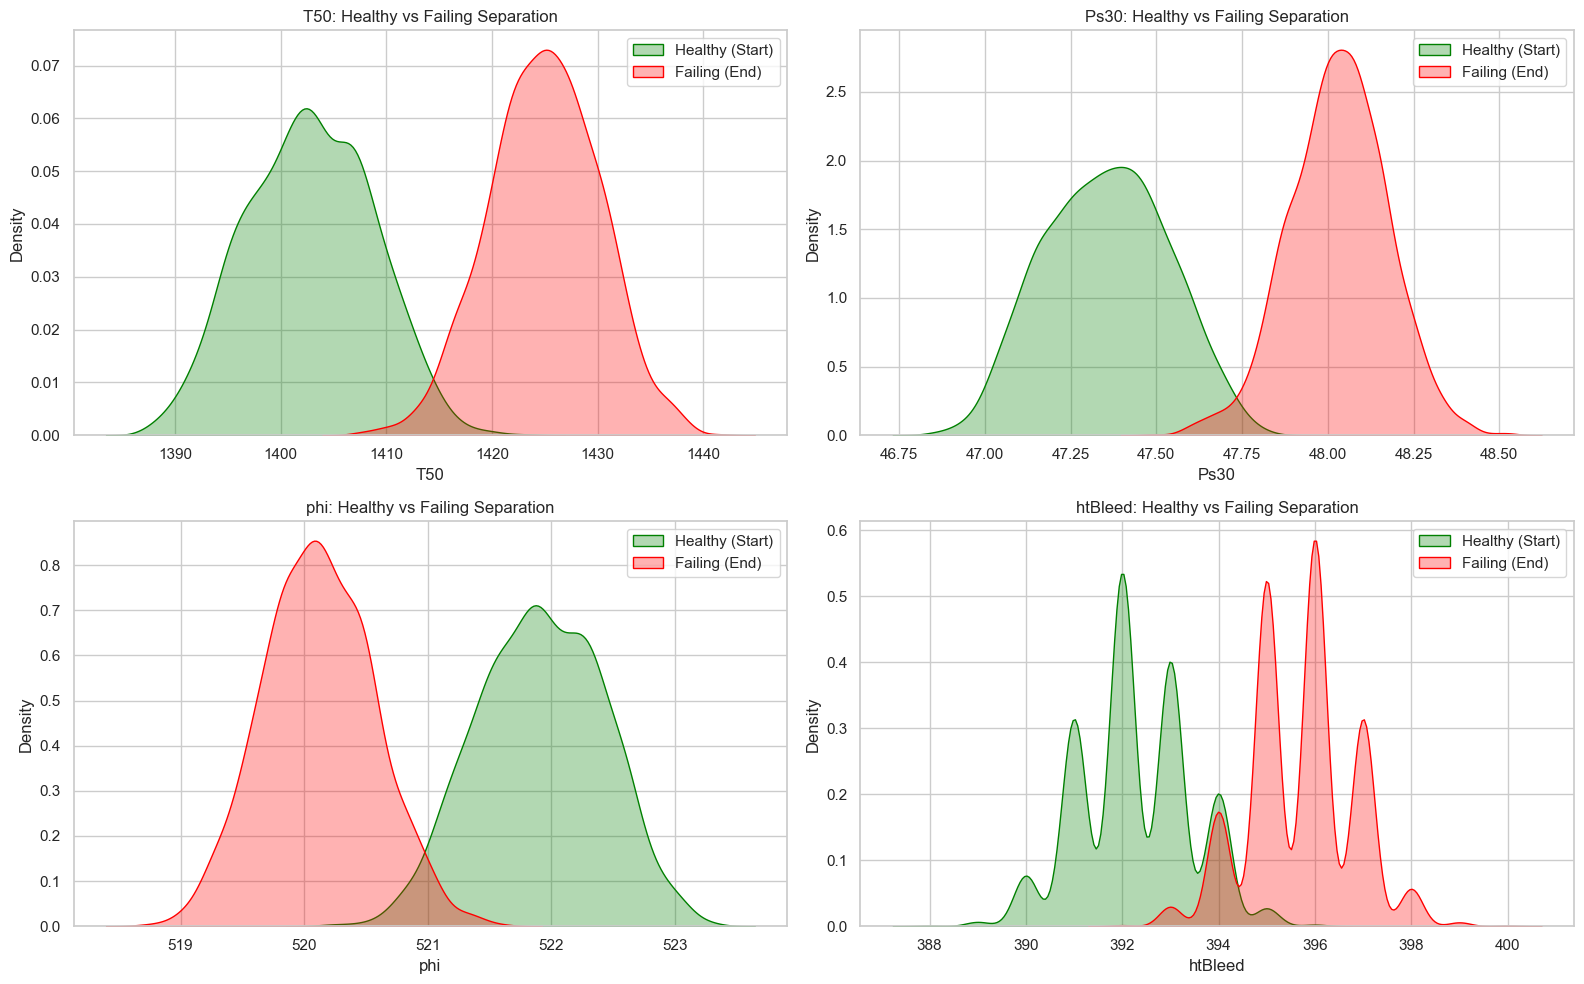

In [24]:
early_life = fd001_train[fd001_train['time_cycles'] < 20]# First 20 cycles
late_life = fd001_train[fd001_train['RUL'] < 20]# Last 20 cycles

sensors_to_compare = ['T50', 'Ps30', 'phi', 'htBleed']
available_sensors = [s for s in sensors_to_compare if s in fd001_train.columns]

if available_sensors:
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
    axes = axes.flatten()

    for i, sensor in enumerate(available_sensors):
        sns.kdeplot(early_life[sensor], fill=True, color="green", label='Healthy (Start)', ax=axes[i], alpha=0.3)
        sns.kdeplot(late_life[sensor], fill=True, color="red", label='Failing (End)', ax=axes[i], alpha=0.3)
        axes[i].set_title(f'{sensor}: Healthy vs Failing Separation')
        axes[i].legend()
    plt.tight_layout()
    plt.show()
else:
    print("Warning: Selected sensors were dropped during cleaning.")

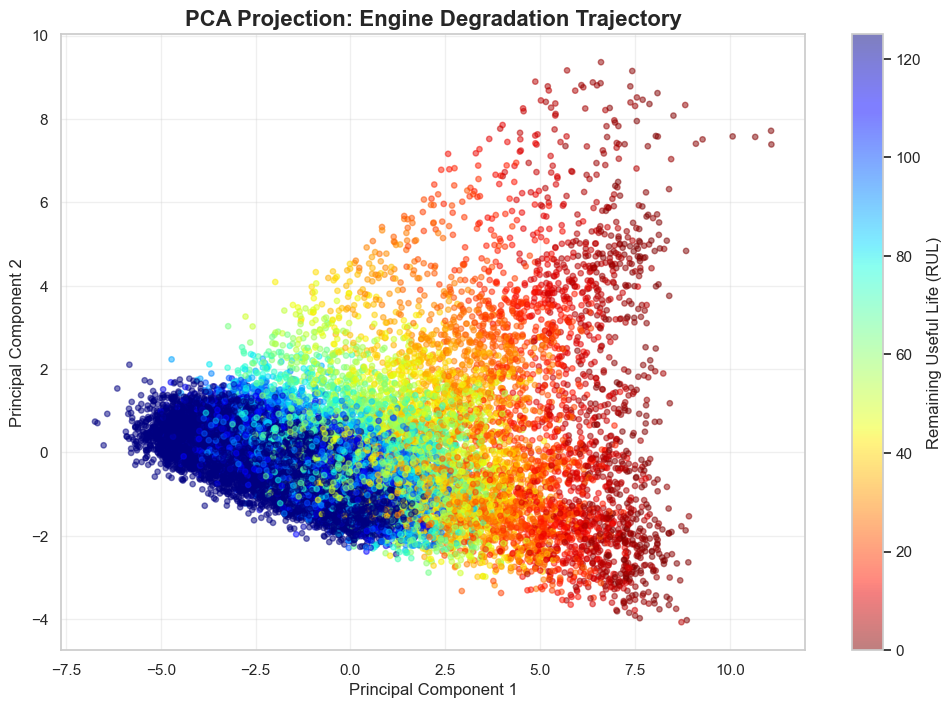

Explained Variance Ratio: 65.44%
Meaning: These 2 components hold 65% of the sensors' information.


In [25]:
features_for_pca = [col for col in fd001_train.columns if col not in ['unit_number', 'time_cycles', 'RUL']]

x_pca = StandardScaler().fit_transform(fd001_train[features_for_pca])

pca = PCA(n_components=2)
principal_components = pca.fit_transform(x_pca)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['RUL'] = fd001_train['RUL']

plt.figure(figsize=(12, 8))
sc = plt.scatter( pca_df['PC1'], pca_df['PC2'], c=pca_df['RUL'],
    cmap='jet_r', alpha=0.5, s=15)

plt.colorbar(sc, label='Remaining Useful Life (RUL)')
plt.title('PCA Projection: Engine Degradation Trajectory', fontsize=16, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_.sum():.2%}")
print("Meaning: These 2 components hold {:.0f}% of the sensors' information.".format(pca.explained_variance_ratio_.sum()*100))

# **Preprocessing & Modeling**

Machine learning algorithms such as **Linear Regression**, **Support Vector Regression (SVR)**, and **Neural Networks** are highly sensitive to the scale of input features. Proper preprocessing is therefore essential to ensure that all variables contribute fairly during model training.

---

## **The Problem: Feature Scale Differences**

Sensor measurements often operate on vastly different scales. For example:

* **T50** may have values ranging from **1000 to 2000**.
* **Ps30** may have values ranging from **10 to 20**.

Without scaling, machine learning models may incorrectly assign greater importance to variables with larger numerical values simply because of their magnitude rather than their predictive significance.

---

## **The Solution: Min-Max Scaling**

To address this issue, we apply **Min-Max Scaling**, which transforms all features into a common range:

[
[0,1]
]

The transformation is defined as:

[
x_{\text{scaled}} =
\frac{x - x_{\min}}
{x_{\max} - x_{\min}}
]

where:

* (x) is the original feature value,
* (x_{\min}) is the minimum value of the feature,
* (x_{\max}) is the maximum value of the feature.

---

## **Why Min-Max Scaling?**

Min-Max Scaling offers several advantages:

* Ensures that all sensor measurements contribute equally during model training.
* Improves convergence speed for optimization algorithms.
* Prevents features with large numerical ranges from dominating the learning process.
* Enhances the performance of distance-based and gradient-based algorithms.

---

## **Critical Rule: Preventing Data Leakage**

To ensure an unbiased model evaluation, the scaler is **fit only on the training data** and then applied to both the training and testing datasets.

### Correct Workflow

```text
Training Data ──► Fit Scaler ──► Transform Training Data
                       │
                       └──────► Transform Test Data
```

### Why This Matters

Fitting the scaler on the entire dataset before splitting would allow information from the test set to influence the training process, a phenomenon known as **data leakage**. This can lead to overly optimistic performance estimates and poor generalization to new data.

---

## **Preprocessing Pipeline**

```text
Raw Sensor Data
        ↓
Train-Test Split
        ↓
Fit Min-Max Scaler on Training Data
        ↓
Transform Training Data
        ↓
Transform Test Data
        ↓
Model Training and Evaluation
```

By carefully scaling the sensor measurements and preventing data leakage, we create a reliable and reproducible preprocessing pipeline that enables robust predictive maintenance modeling.


In [26]:
# Select features to scale
## We exclude 'unit_number', 'time_cycles', and 'RUL' because they are identifiers/targets, not sensor inputs.

features_to_normalize = [col for col in fd001_train.columns if col not in ['unit_number', 'time_cycles', 'RUL']]
scaler = MinMaxScaler()
fd001_train[features_to_normalize] = scaler.fit_transform(fd001_train[features_to_normalize])
fd001_test[features_to_normalize] = scaler.transform(fd001_test[features_to_normalize])


print("\nScaling completed successfully.")
print(f"Features Scaled: {len(features_to_normalize)}")

print("Data Scaling Completed (Range 0-1).")
print('-' * 30 + '\nData Preview after Scaling (Train) :\n')
display(fd001_train.head())

print('-' * 30 + '\nCheck Min/Max values (Should be 0 and 1) :\n')
display(fd001_train[features_to_normalize].describe().loc[['min', 'max']])


Scaling completed successfully.
Features Scaled: 17
Data Scaling Completed (Range 0-1).
------------------------------
Data Preview after Scaling (Train) :



,unit_number,time_cycles,setting_1,setting_2,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,RUL
0,1,1,0.459770,0.166667,0.183735,0.406802,0.309757,1.0,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,125
1,1,2,0.609195,0.250000,0.283133,0.453019,0.352633,1.0,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,125
2,1,3,0.252874,0.750000,0.343373,0.369523,0.370527,1.0,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,125
3,1,4,0.540230,0.500000,0.343373,0.256159,0.331195,1.0,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,125
4,1,5,0.390805,0.333333,0.349398,0.257467,0.404625,1.0,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,125


------------------------------
Check Min/Max values (Should be 0 and 1) :



,setting_1,setting_2,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


# **Splitting Data for Model Evaluation**

The **NASA C-MAPSS Predictive Maintenance Challenge** uses a specific evaluation methodology that differs from traditional machine learning train-test splits. Understanding this evaluation strategy is essential for building a model that accurately estimates the **Remaining Useful Life (RUL)** of turbofan engines.

---

## **Training Dataset**

For the training dataset, we are provided with the **complete operational history** of each engine unit, from its initial healthy state until failure.

This allows the model to learn:

* Normal operating behavior
* Sensor degradation patterns
* Relationships between sensor measurements and engine failure

```text id="wk6mzi"
Engine 1: Cycle 1 ─────────► Failure
Engine 2: Cycle 1 ─────────► Failure
Engine 3: Cycle 1 ─────────► Failure
```

---

## **Testing Dataset**

The testing dataset is structured differently.

For each test engine, we are only given a **partial operational history**, meaning that the engine has not yet failed within the provided data.

The objective is to predict:

> **How many cycles remain before the engine fails?**

```text id="lr2rjg"
Engine 1: Cycle 1 ─────► Last Observed Cycle ?
Engine 2: Cycle 1 ─────► Last Observed Cycle ?
Engine 3: Cycle 1 ─────► Last Observed Cycle ?
```

---

## **Evaluation Strategy**

The official NASA challenge evaluates model performance by comparing predictions against the **ground truth file**:

```text id="mmlbvi"
RUL_FD001.txt
```

This file contains the actual Remaining Useful Life values for each test engine after its final observed cycle.

---

## **Constructing the Test Set**

To follow the official evaluation protocol, we extract **only the final recorded observation** for each engine unit in the test dataset.

Mathematically,

```text id="kplwq4"
X_test = Last Observation of Each Engine
```

This ensures that:

* Each engine contributes a single prediction.
* Predictions are directly comparable to the values contained in `RUL_FD001.txt`.
* The evaluation procedure matches the original NASA benchmark.

---

## **Why Use Only the Last Observation?**

The business objective of predictive maintenance is to answer a practical question:

> **Given the current condition of an operating engine, how much useful life remains before failure?**

In real-world applications, maintenance teams only have access to the **latest sensor readings** when making maintenance decisions. Therefore, using the final observation of each engine closely mimics real operational scenarios.

---

## **Data Splitting Workflow**

```text id="xq76na"
Training Dataset
      ↓
Complete Engine Histories
      ↓
Train Machine Learning Model

Testing Dataset
      ↓
Partial Engine Histories
      ↓
Select Last Observation for Each Engine
      ↓
Predict Remaining Useful Life
      ↓
Compare Predictions with RUL_FD001.txt
```

This evaluation framework provides a realistic assessment of the model's ability to estimate engine health and supports the development of reliable predictive maintenance systems capable of reducing unplanned downtime.


In [27]:
X_train = fd001_train[features_to_normalize]
y_train = fd001_train['RUL']

# We need to predict RUL at the LAST observed time cycle for each unit in the test set.
X_test_last_cycle = fd001_test.groupby('unit_number').last().reset_index()
X_test = X_test_last_cycle[features_to_normalize]
y_true = rul['RUL'] # y_true: The actual Ground Truth RUL from the provided file

print(f"Training Data: X={X_train.shape}, y={y_train.shape}")
print(f"Testing Data:  X={X_test.shape},  y={y_true.shape}")

# Safety Check: Ensure we have one prediction target per test unit
assert X_test.shape[0] == y_true.shape[0], "Error: Mismatch in Test Data dimensions!"

Training Data: X=(20631, 17), y=(20631,)
Testing Data:  X=(100, 17),  y=(100,)


# **Modeling & Benchmarking**

With the data cleaned and preprocessed, the next step is to train and evaluate multiple machine learning algorithms to determine which model provides the most accurate predictions of **Remaining Useful Life (RUL)**.

The objective is not simply to build a complex model, but to identify the approach that delivers the best balance between **predictive performance**, **computational efficiency**, and **generalization to unseen engines**.

---

## **Modeling Strategy**

The experimentation follows a progressive approach:

> **Start with simple models and gradually increase model complexity.**

This strategy helps determine whether more sophisticated algorithms genuinely provide meaningful performance improvements over simpler methods.

---

## **Models Evaluated**

### 1. Linear Regression (Baseline Model)

Linear Regression serves as the benchmark model.

#### Why Use It?

* Simple and highly interpretable.
* Computationally efficient.
* Establishes a baseline level of performance.

If more advanced models do not significantly outperform Linear Regression, the additional complexity and computational cost may not be justified.

---

### 2. Support Vector Regressor (SVR)

Support Vector Regression extends the principles of Support Vector Machines to regression problems.

#### Strengths

* Effective in high-dimensional feature spaces.
* Capable of modeling non-linear relationships through kernel functions.
* Often performs well on complex datasets.

#### Limitations

* Computationally expensive for large datasets.
* Requires careful hyperparameter tuning.

---

### 3. Random Forest Regressor

Random Forest is an ensemble learning technique that combines multiple decision trees to improve prediction accuracy.

#### Strengths

* Handles non-linear relationships effectively.
* Robust to noise and outliers.
* Reduces overfitting through ensemble averaging.
* Provides feature importance measures.

#### Limitations

* Less interpretable than linear models.
* Can become computationally intensive with large numbers of trees.

---

### 4. XGBoost Regressor

Extreme Gradient Boosting (**XGBoost**) is one of the most powerful machine learning algorithms for structured tabular data.

#### Strengths

* Captures complex non-linear relationships.
* Includes built-in regularization to reduce overfitting.
* Highly efficient and scalable.
* Consistently delivers state-of-the-art performance in predictive modeling competitions, including many winning solutions on **Kaggle**.

Because of its strong predictive capabilities, XGBoost is often considered the industry standard for tabular machine learning problems.

---

# **Model Evaluation Metrics**

To compare model performance objectively, two primary evaluation metrics are used.

---

## **Root Mean Squared Error (RMSE)**

RMSE measures the average magnitude of prediction errors and is expressed in the same units as the target variable—in this case, **engine cycles**.

[
RMSE =
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
}
]

where:

* (y_i) is the actual Remaining Useful Life,
* (\hat{y}_i) is the predicted Remaining Useful Life,
* (n) is the number of observations.

### Interpretation

```text id="m9r9m2"
RMSE = 20
```

means that, on average, the model's predictions are off by approximately **20 operational cycles**.

Lower RMSE values indicate better predictive performance.

---

## **Coefficient of Determination (R² Score)**

The R² Score measures how well the model explains the variability in Remaining Useful Life.

[
R^2 =
1 -
\frac{\sum (y_i-\hat{y}_i)^2}
{\sum (y_i-\bar{y})^2}
]

where:

* (y_i) is the actual RUL,
* (\hat{y}_i) is the predicted RUL,
* (\bar{y}) is the mean RUL.

### Interpretation

| R² Score | Interpretation      |
| -------- | ------------------- |
| 1.0      | Perfect prediction  |
| 0.9      | Excellent fit       |
| 0.7      | Good fit            |
| 0.5      | Moderate fit        |
| 0.0      | No predictive power |

Higher R² values indicate that the model explains a greater proportion of the variability in engine degradation.

---

# **Benchmarking Workflow**

```text id="w44wfd"
Preprocessed Dataset
          ↓
Train Multiple Models
          ↓
Linear Regression
SVR
Random Forest
XGBoost
          ↓
Evaluate Performance
(RMSE and R²)
          ↓
Select Best Model
          ↓
Predict Remaining Useful Life
```

By systematically benchmarking multiple algorithms, we can identify the model that most accurately predicts engine degradation and provides the strongest foundation for a **Predictive Maintenance System** capable of reducing unplanned downtime and optimizing maintenance scheduling.


In [28]:
results_summary = []

def evaluate_model(model, X_train, y_train, X_test, y_true, model_name):
    """
    Standardized evaluation function:
    1. Fits the model
    2. Predicts on Test Data (Last Cycle)
    3. Calculates Metrics (RMSE, R2)
    4. Plots Actual vs Predicted RUL
    """
    model.fit(X_train, y_train)  # Train
    y_pred = model.predict(X_test)  # Predict

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # Score
    r2 = r2_score(y_true, y_pred)

    # Log results
    results_summary.append({
        'Model': model_name,
        'RMSE': rmse,
        'R2 Score': r2
    })

    # Summary
    print(f"--- {model_name} Results ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2:   {r2:.2%}")

    # Plot Predictions
    plt.figure(figsize=(10, 5))
    plt.plot(y_true.values, label='Actual RUL', linestyle='--')
    plt.plot(y_pred, label=f'Predicted ({model_name})')
    plt.xlabel('Test Units Index')
    plt.ylabel('Remaining Useful Life (RUL)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return y_pred

Training Linear Regression (Baseline)...
--- Linear Regression Results ---
RMSE: 21.90
R2:   72.22%


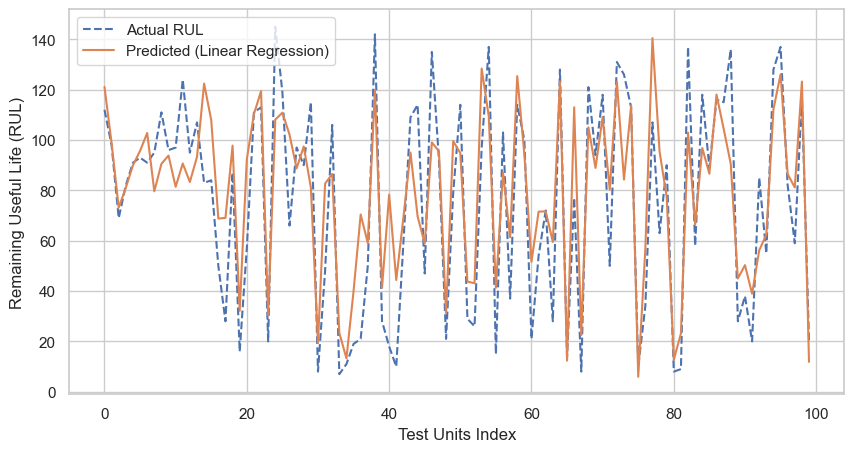

In [29]:
# Linear Regression (Baseline)

lr_model = LinearRegression()
print("Training Linear Regression (Baseline)...")
_ = evaluate_model(lr_model, X_train, y_train, X_test, y_true, "Linear Regression")

--- SVR Results ---
RMSE: 19.84
R2:   77.20%


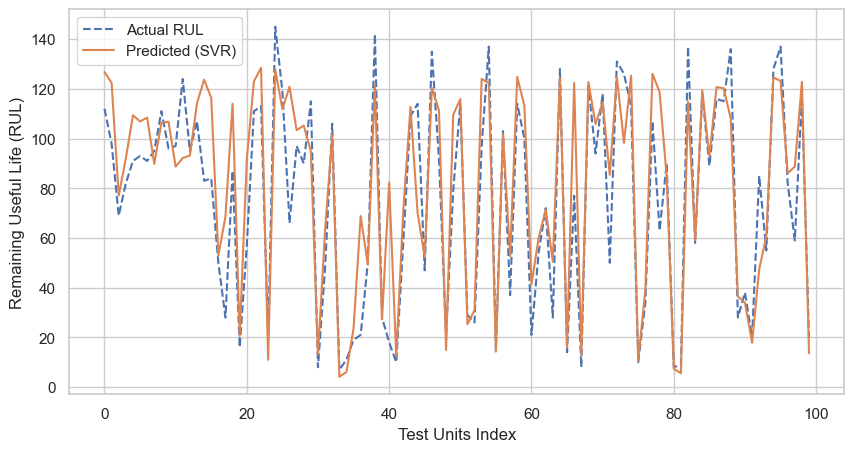

In [30]:
# Support Vector Regressor (SVR)

svr_model = SVR(kernel='rbf', C=10, epsilon=0.1)  # Kernel='rbf' for non-linear relationships

_ = evaluate_model(svr_model, X_train, y_train, X_test, y_true, "SVR")

--- Random Forest Results ---
RMSE: 18.16
R2:   80.91%


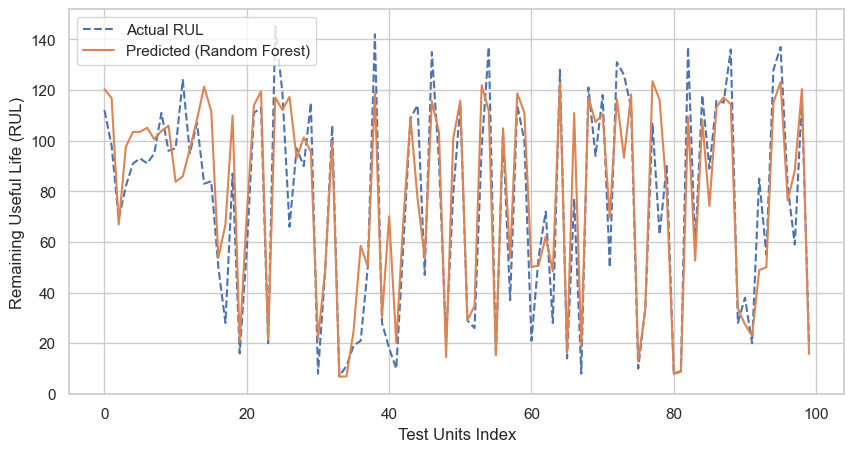

In [31]:
# Random Forest Regressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)

_ = evaluate_model(rf_model, X_train, y_train, X_test, y_true, "Random Forest")

--- XGBoost Results ---
RMSE: 17.69
R2:   81.87%


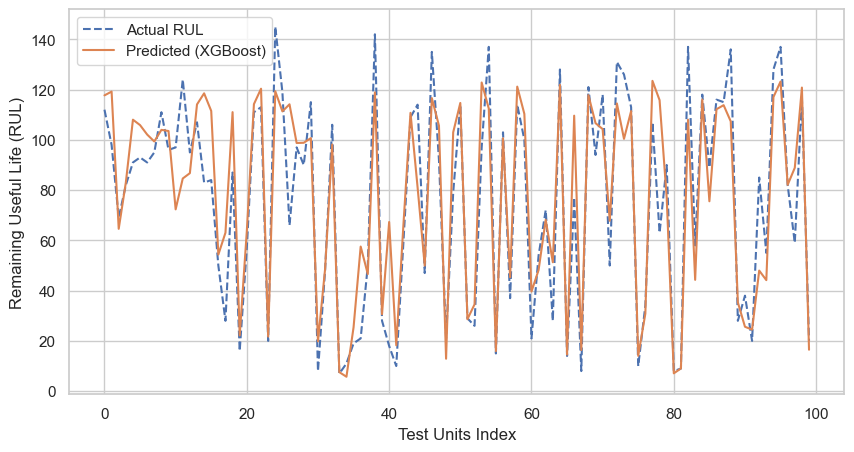

In [32]:
# XGBoost Regressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, n_jobs=-1, random_state=42)

_ = evaluate_model(xgb_model, X_train, y_train, X_test, y_true, "XGBoost")


 FINAL MODEL COMPARISON 


,Model,RMSE,R2 Score
3,XGBoost,17.692938,0.818724
2,Random Forest,18.158424,0.809060
1,SVR,19.844600,0.771953
0,Linear Regression,21.904171,0.722160


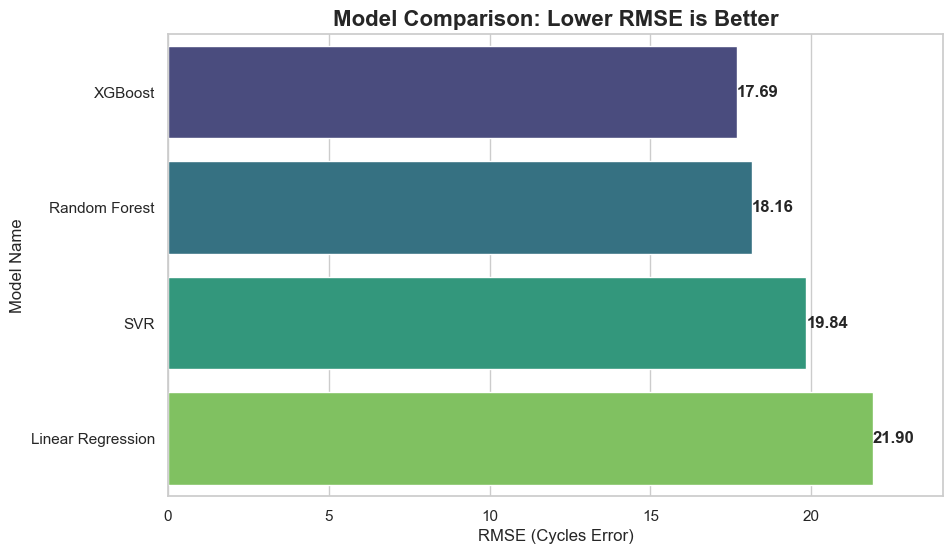

The Best Model is: XGBoost


In [33]:
results_df = pd.DataFrame(results_summary).sort_values(by='RMSE')

print("\n FINAL MODEL COMPARISON ")
display(results_df.style.background_gradient(cmap='Greens_r', subset=['RMSE']))

# plot Leaderboard
plt.figure(figsize=(10, 6))
sns.barplot(x='RMSE', y='Model', data=results_df, palette='viridis')
plt.title('Model Comparison: Lower RMSE is Better', fontsize=16, fontweight='bold')
plt.xlabel('RMSE (Cycles Error)', fontsize=12)
plt.ylabel('Model Name', fontsize=12)
# Add value labels
for index, value in enumerate(results_df['RMSE']):
    plt.text(value, index, f'{value:.2f}', va='center', fontsize=12, fontweight='bold')

plt.xlim(0, max(results_df['RMSE'])*1.1)
plt.show()

print(f"The Best Model is: {results_df.iloc[0]['Model']}")

In [34]:
# Save Artifacts for Production

best_model = xgb_model
joblib.dump(best_model, 'best_rul_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler saved successfully!")
print("Files created: 'best_rul_model.pkl', 'scaler.pkl'")
print("Ready for deployment in Web App or API.")

Model and Scaler saved successfully!
Files created: 'best_rul_model.pkl', 'scaler.pkl'
Ready for deployment in Web App or API.


In [35]:
best_model = xgb_model
joblib.dump(best_model, 'best_rul_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler saved successfully!")
print("Files created: 'best_rul_model.pkl', 'scaler.pkl'")
print("Ready for deployment in Web App or API.")

Model and Scaler saved successfully!
Files created: 'best_rul_model.pkl', 'scaler.pkl'
Ready for deployment in Web App or API.


## Real-Time Simulation (Digital Twin)

Evaluation metrics such as RMSE provide useful performance summaries, but they can be abstract and difficult to interpret. To build deeper trust in the model, it is important to observe how it behaves in a realistic, time-based scenario.

In this step, we perform a **Trajectory Reconstruction** to simulate real-world usage:

- Select a random engine from the test dataset (e.g., **Unit #24**)
- Feed its sensor data **cycle-by-cycle** into the trained model
- Compare the **predicted Remaining Useful Life (RUL)** with the **actual RUL** over time

This visualization demonstrates that the model is not simply making static predictions. Instead, it continuously tracks the degradation pattern of the engine, capturing how failure risk evolves as operational cycles increase.

Ultimately, this "digital twin" simulation provides a more intuitive and convincing validation of the model’s ability to monitor and predict equipment health in real time.

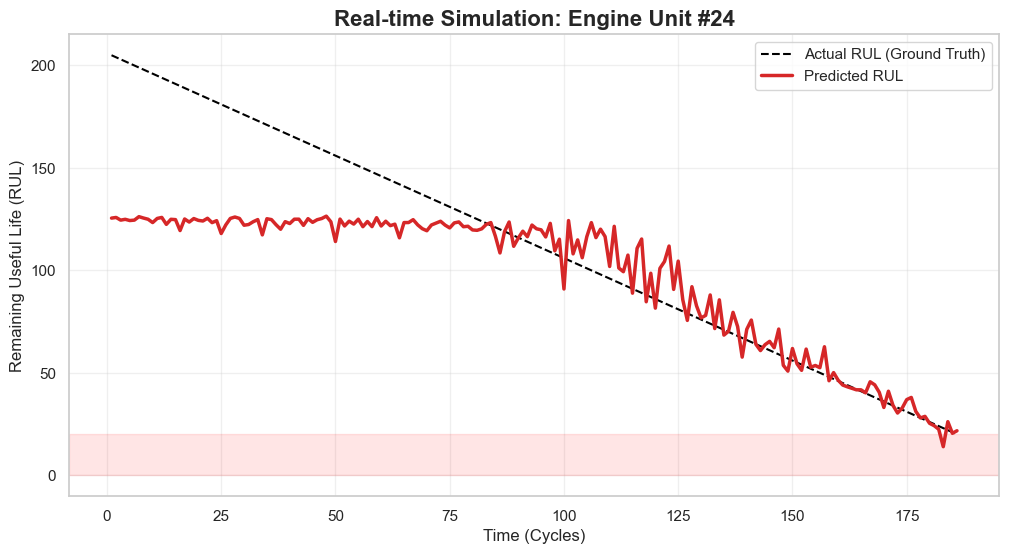

In [36]:
def simulate_engine_life(unit_id, model, scaler, data_test, true_rul_df):
    """
    Simulates the RUL prediction for a single engine unit over its entire history.
    Visualizes the 'Actual' vs 'Predicted' degradation path.
    """
    # Take the data for the specific unit
    # Note: data_test is ALREADY scaled
    engine_data = data_test[data_test['unit_number'] == unit_id].copy()
    # Extract features directly
    X_engine = engine_data[features_to_normalize]
    pred_rul = model.predict(X_engine) # Predict
    #Construct Ground Truth (Actual RUL) for visualization
    # We know the Final RUL from the file, so we back-calculate the path.
    final_true_rul = true_rul_df.iloc[unit_id - 1]['RUL']
    max_cycle = engine_data['time_cycles'].max()
    true_rul_series = []
    current_rul = final_true_rul + max_cycle
    for _ in range(len(engine_data)):
        current_rul -= 1
        true_rul_series.append(current_rul)

    plt.figure(figsize=(12, 6))
    plt.plot(engine_data['time_cycles'], true_rul_series, color='black', linestyle='--', label='Actual RUL (Ground Truth)')
    plt.plot(engine_data['time_cycles'], pred_rul, color='#d62728', linewidth=2.5, label='Predicted RUL')
    plt.title(f'Real-time Simulation: Engine Unit #{unit_id}', fontsize=16, fontweight='bold')
    plt.xlabel('Time (Cycles)', fontsize=12)
    plt.ylabel('Remaining Useful Life (RUL)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axhspan(0, 20, color='red', alpha=0.1, label='Failure Zone')
    plt.show()


# Simulate Engine Unit #24
simulate_engine_life(24, best_model, scaler, fd001_test, rul)


## 🔄 Extension: From Sensor Data to Inventory Optimization

This section extends the original predictive maintenance model into a **business-focused decision system** by connecting sensor-based failure predictions to inventory and supply chain actions.

### ✅ What Was Added

- Mapped sensor data to **components (PartID)** to simulate real-world parts usage
- Created **maintenance records** based on predicted failures (RUL ≤ 30)
- Built a synthetic **inventory dataset** including stock levels, lead times, and costs
- Generated **parts demand** from failure events

---

### ✅ Inventory Optimization Logic

Introduced decision rules to support supply chain actions:

- Identified **low stock conditions**
- Incorporated **supplier lead time constraints**
- Created an automated **reorder decision system**



In [38]:
sensor_data = fd001_train.copy()


In [39]:
import numpy as np

sensor_data["VehicleID"] = sensor_data["unit_number"]
sensor_data["Date"] = pd.date_range(start="2023-01-01", periods=len(sensor_data))
sensor_data["PartID"] = np.random.choice(
    ["Engine", "Brake", "Cooling", "Transmission"],
    size=len(sensor_data)
)

In [40]:
sensor_data["Failure_30_Days"] = (sensor_data["RUL"] <= 30).astype(int)

In [41]:
from sklearn.ensemble import RandomForestClassifier

features = ["T50", "Ps30"]   # use your selected sensors
target = "Failure_30_Days"

clf = RandomForestClassifier()
clf.fit(sensor_data[features], sensor_data[target])

RandomForestClassifier()

In [42]:
from sklearn.metrics import classification_report

preds = clf.predict(sensor_data[features])
print(classification_report(sensor_data[target], preds))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17531
           1       1.00      0.98      0.99      3100

    accuracy                           1.00     20631
   macro avg       1.00      0.99      0.99     20631
weighted avg       1.00      1.00      1.00     20631



In [43]:
inventory = pd.DataFrame({
    "PartID": ["Engine", "Brake", "Cooling", "Transmission"],
    "Stock": [50, 80, 40, 30],
    "LeadTime": [20, 10, 15, 25],
    "Cost": [2000, 500, 800, 1500]
})

In [44]:
maintenance = sensor_data[sensor_data["Failure_30_Days"] == 1][
    ["VehicleID", "PartID"]
].copy()

maintenance["RepairCost"] = np.random.randint(200, 2000, len(maintenance))

In [45]:
demand = maintenance.groupby("PartID").size().reset_index(name="Demand")


In [46]:
inventory["StockoutRisk"] = inventory["Stock"] < 40


In [47]:
inventory["ReorderQty"] = np.where(
    inventory["Stock"] < 40,
    100 - inventory["Stock"],
    0
)

In [48]:
inventory["Action"] = np.where(
    (inventory["Stock"] < 40) & (inventory["LeadTime"] > 15),
    "URGENT REORDER",
    "Stable"
)

In [49]:
maintenance["Date"] = pd.date_range(start="2023-01-01", periods=len(maintenance))

In [50]:
demand_ts = maintenance.groupby(
    [pd.Grouper(key="Date", freq="M"), "PartID"]
).size().reset_index(name="Demand")

In [51]:
from sklearn.ensemble import RandomForestRegressor

demand_ts["Month"] = demand_ts["Date"].dt.month

model = RandomForestRegressor()
model.fit(demand_ts[["Month"]], demand_ts["Demand"])

RandomForestRegressor()

## 🔍 SHAP Interaction Analysis

The SHAP interaction plots show that the selected sensor features (Ps30 and T50) have minimal interaction effects.

Most interaction values are centered near zero, indicating that each feature contributes independently to the model predictions.

This suggests a stable and interpretable model, where predictions are driven primarily by individual sensor behavior rather than complex feature interactions.


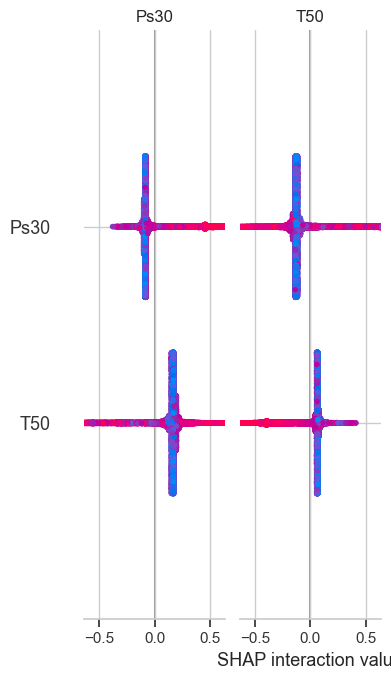

In [52]:
import shap

explainer = shap.Explainer(clf)
shap_values = explainer(sensor_data[features])

shap.summary_plot(shap_values, sensor_data[features])

In [54]:
fact_predictions = sensor_data[[
    "VehicleID",
    "PartID",
    "RUL",
    "Failure_30_Days"
]].copy()

In [55]:
fact_demand = demand_ts.copy()

In [56]:
inventory = inventory.copy() 

In [57]:
download_path = r"C:\Users\mensahs2\Downloads"

fact_predictions.to_csv(f"{download_path}\Fact_Predictions.csv", index=False)
fact_demand.to_csv(f"{download_path}\Fact_Demand.csv", index=False)
inventory.to_csv(f"{download_path}\Inventory.csv", index=False)

In [1]:
pip install snowflake-connector-python pandas

INFO: pip is looking at multiple versions of pyopenssl to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/5.4 MB ? eta -:--:--
   --- ------------------------------------ 0.5/5.4 MB 3.5 MB/s eta 0:00:02
   --------- ------------------------------ 1.3/5.4 MB 3.5 MB/s eta 0:00:02
   --------------- ------------------------ 2.1/5.4 MB 3.7 MB/s eta 0:00:01
   --------------------- ------------------ 2.9/5.4 MB 3.9 MB/s eta 0:00:01
   ----------------------------- ---------- 3.9/5.4 MB 4.0 MB/s eta 0:00:01
   --------------------------------- ------ 4.5/5.4 MB 3.8 MB/s eta 0:00:01
   -------------------------------------- - 5.2/5.4 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 5.4/5.4 MB 3.7 MB/s  0:00:01
   ---------------------------------------- 0.0/15.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/15.3 MB 4.4 MB/s eta 0:00:04
   ---- -------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiobotocore 2.19.0 requires botocore<1.36.4,>=1.36.0, but you have botocore 1.43.40 which is incompatible.
spyder 6.0.7 requires ipython!=8.17.1,<9.0.0,>=8.13.0; python_version > "3.8", but you have ipython 9.5.0 which is incompatible.


In [18]:
import pandas as pd
import snowflake.connector
from snowflake.connector.pandas_tools import write_pandas

# 1. Setup your Snowflake Connection Parameters
# (In a real enterprise, you would hide these in a .env file!)
conn_params = {
    "user": "mensahs2",  # Replace with the email/username you used to sign up
    "password": "6Bs.nPKeRgbsQPT",       # Replace with your actual password
    "account": "QKJOKPZ-VM64692",                # <-- Your exact account identifier!
    "warehouse": "nfi_compute_wh",
    "database": "NFI_PARTS_OPTIMIZER",
    "schema": "gold_business",
    "role": "ACCOUNTADMIN" 
}

print("Connecting to Snowflake...")
conn = snowflake.connector.connect(**conn_params)
print("Connected Successfully!")

# ---------------------------------------------------------
# 2. Prepare your DataFrames (Make sure columns match SQL!)
# ---------------------------------------------------------
# NOTE: Ensure your DataFrame column names are UPPERCASE because 
# Snowflake defaults to uppercase column names.

# Example: Formatting your predictions dataframe
# ---------------------------------------------------------
# 2. Prepare your DataFrames (Read from your saved CSVs)
# ---------------------------------------------------------
import pandas as pd

print("Loading CSV files from local directory...")

# Point to where you saved the files earlier
download_path = r"C:\Users\mensahs2\Downloads"

# Read the CSVs into pandas DataFrames
fact_predictions_df = pd.read_csv(f"{download_path}\\Fact_Predictions.csv")
# Note: Check if your inventory file was saved as 'inventory.csv' or 'Fact_Inventory.csv' 
# and update the filename below if needed!
inventory_df = pd.read_csv(f"{download_path}\\inventory.csv") 

# Format for Snowflake: Snowflake requires all column names to be UPPERCASE
print("Formatting columns for Snowflake...")
fact_predictions_df.columns = [col.upper() for col in fact_predictions_df.columns]
inventory_df.columns = [col.upper() for col in inventory_df.columns]

print("DataFrames ready for upload!")
# You can do the same for dim_part, dim_vehicle, etc.

# Close the connection when done
conn.close()

Connecting to Snowflake...
Connected Successfully!
Loading CSV files from local directory...
Formatting columns for Snowflake...
DataFrames ready for upload!


In [23]:
import pandas as pd
import snowflake.connector
from snowflake.connector.pandas_tools import write_pandas

# 1. Establish the Connection
print("Connecting to Snowflake...")
conn_params = {
    "user": "mensahs2", 
    "password": "6Bs.nPKeRgbsQPT",      # <-- Put your real password here
    "account": "QKJOKPZ-VM64692",               
    "warehouse": "nfi_compute_wh",
    "database": "NFI_PARTS_OPTIMIZER",
    "schema": "gold_business",
    "role": "ACCOUNTADMIN" 
}
conn = snowflake.connector.connect(**conn_params)
print("Connected Successfully!")

# 2. Read and deeply clean the DataFrames
print("Loading CSV files...")
download_path = r"C:\Users\mensahs2\Downloads"

fact_predictions_df = pd.read_csv(f"{download_path}\\Fact_Predictions.csv")
inventory_df = pd.read_csv(f"{download_path}\\inventory.csv") 

# STRIP hidden spaces and uppercase to guarantee clean headers
fact_predictions_df.columns = [col.upper().strip() for col in fact_predictions_df.columns]
inventory_df.columns = [col.upper().strip() for col in inventory_df.columns]

# 3. Define the Bulletproof Upload Function
def load_to_snowflake_bulletproof(connection, dataframe, table_name):
    print(f"Uploading data to {table_name}...")
    
    # Drop the old table if it exists so we start completely fresh
    connection.cursor().execute(f"DROP TABLE IF EXISTS {table_name}")
    
    # auto_create_table=True is the magic fix! It builds the table for you.
    success, num_chunks, num_rows, output = write_pandas(
        conn=connection,
        df=dataframe,
        table_name=table_name.upper(),
        auto_create_table=True 
    )
    if success:
        print(f"✅ Successfully loaded {num_rows} rows into {table_name}.")
    else:
        print(f"❌ Failed to load data into {table_name}.")

# 4. Execute the Uploads
load_to_snowflake_bulletproof(conn, inventory_df, "FACT_INVENTORY")
load_to_snowflake_bulletproof(conn, fact_predictions_df, "FACT_PREDICTIONS")

# 5. Close the Connection
print("Closing connection...")
conn.close()
print("Pipeline Complete!")

Connecting to Snowflake...
Connected Successfully!
Loading CSV files...
Uploading data to FACT_INVENTORY...
✅ Successfully loaded 4 rows into FACT_INVENTORY.
Uploading data to FACT_PREDICTIONS...
✅ Successfully loaded 20631 rows into FACT_PREDICTIONS.
Closing connection...
Pipeline Complete!


In [22]:
# 1. Re-establish the Connection (Crucial: Re-open it right before use)
print("Re-connecting to Snowflake...")
conn = snowflake.connector.connect(**conn_params) 

# 2. Execute the Uploads
try:
    load_to_snowflake_bulletproof(conn, inventory_df, "FACT_INVENTORY")
    load_to_snowflake_bulletproof(conn, fact_predictions_df, "FACT_PREDICTIONS")
finally:
    # 3. Close the Connection only after everything is done
    print("Closing connection...")
    conn.close()
    print("Pipeline Complete!")

Re-connecting to Snowflake...
Uploading data to FACT_INVENTORY...
✅ Successfully loaded 4 rows into FACT_INVENTORY.
Uploading data to FACT_PREDICTIONS...
✅ Successfully loaded 20631 rows into FACT_PREDICTIONS.
Closing connection...
Pipeline Complete!


In [25]:
print(fact_predictions_df.columns)

Index(['VEHICLEID', 'PARTID', 'RUL', 'FAILURE_30_DAYS'], dtype='object')
